In [21]:
# Benchmark Visualization — TCC Streaming Vital-Signs Pipeline
#
# Visualizes every layer touched by Milestone 1: synthetic signal generation
# (with inter-signal correlation + scenario trajectories), transport noise
# injection, NEWS2 composite scoring (Approaches A/B/C), and the aggregate
# benchmark results (TPR/FPR/detection latency/alarm rate) from the full
# 10-seed-pair x 6-scenario sweep.
#
# All simulation logic here re-uses the actual project modules (no
# reimplementation) via `scripts/run_benchmark.py`'s `_simulate_run(..., record=[])`
# hook, so every chart reflects the real scoring/generation code, not a mock.

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from run_benchmark import _simulate_run, SCENARIOS
from data.generators.noise import NoiseConfig

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

BENCHMARK_CSV = PROJECT_ROOT / "benchmark_results.csv"
DEFAULT_NOISE = NoiseConfig(packet_loss_rate=0.01, spike_probability=0.005, clock_drift_ms=50)
SCENARIO_ORDER = list(SCENARIOS.keys())

## 1. Signal Generation & Scenario Trajectories

One deterministic run (fixed `signal_seed`/`noise_seed`) per scenario, using the same generators + correlation + scenario-delta pipeline as the live producer. The dashed vertical line marks `onset_offset_ms` — the exact ground-truth deterioration timestamp each scenario defines.

In [22]:
# Run each scenario once with recording enabled, collect into one long-form DataFrame.
DEMO_SEED = 42

records = []
for scenario_id, scenario in SCENARIOS.items():
    rec = []
    _simulate_run(scenario, DEMO_SEED, DEMO_SEED + 1, DEFAULT_NOISE, record=rec)
    for row in rec:
        row["scenario"] = scenario_id
        row["onset_offset_ms"] = scenario.onset_offset_ms
    records.extend(rec)

sim_df = pd.DataFrame(records)
signals_df = sim_df[sim_df["kind"] == "signal"].copy()
signals_df["elapsed_s"] = signals_df["elapsed_ms"] / 1000
signals_df.head()

,elapsed_ms,kind,signal_type,value,scenario,onset_offset_ms,news2_score,level,elapsed_s
0,-32,signal,heart_rate,74.800,sepsis_progression,60000,NaN,NaN,-0.032
1,39,signal,spo2,96.908,sepsis_progression,60000,NaN,NaN,0.039
2,13,signal,systolic_bp,118.900,sepsis_progression,60000,NaN,NaN,0.013
3,13,signal,diastolic_bp,77.100,sepsis_progression,60000,NaN,NaN,0.013
4,23,signal,respiratory_rate,16.000,sepsis_progression,60000,NaN,NaN,0.023


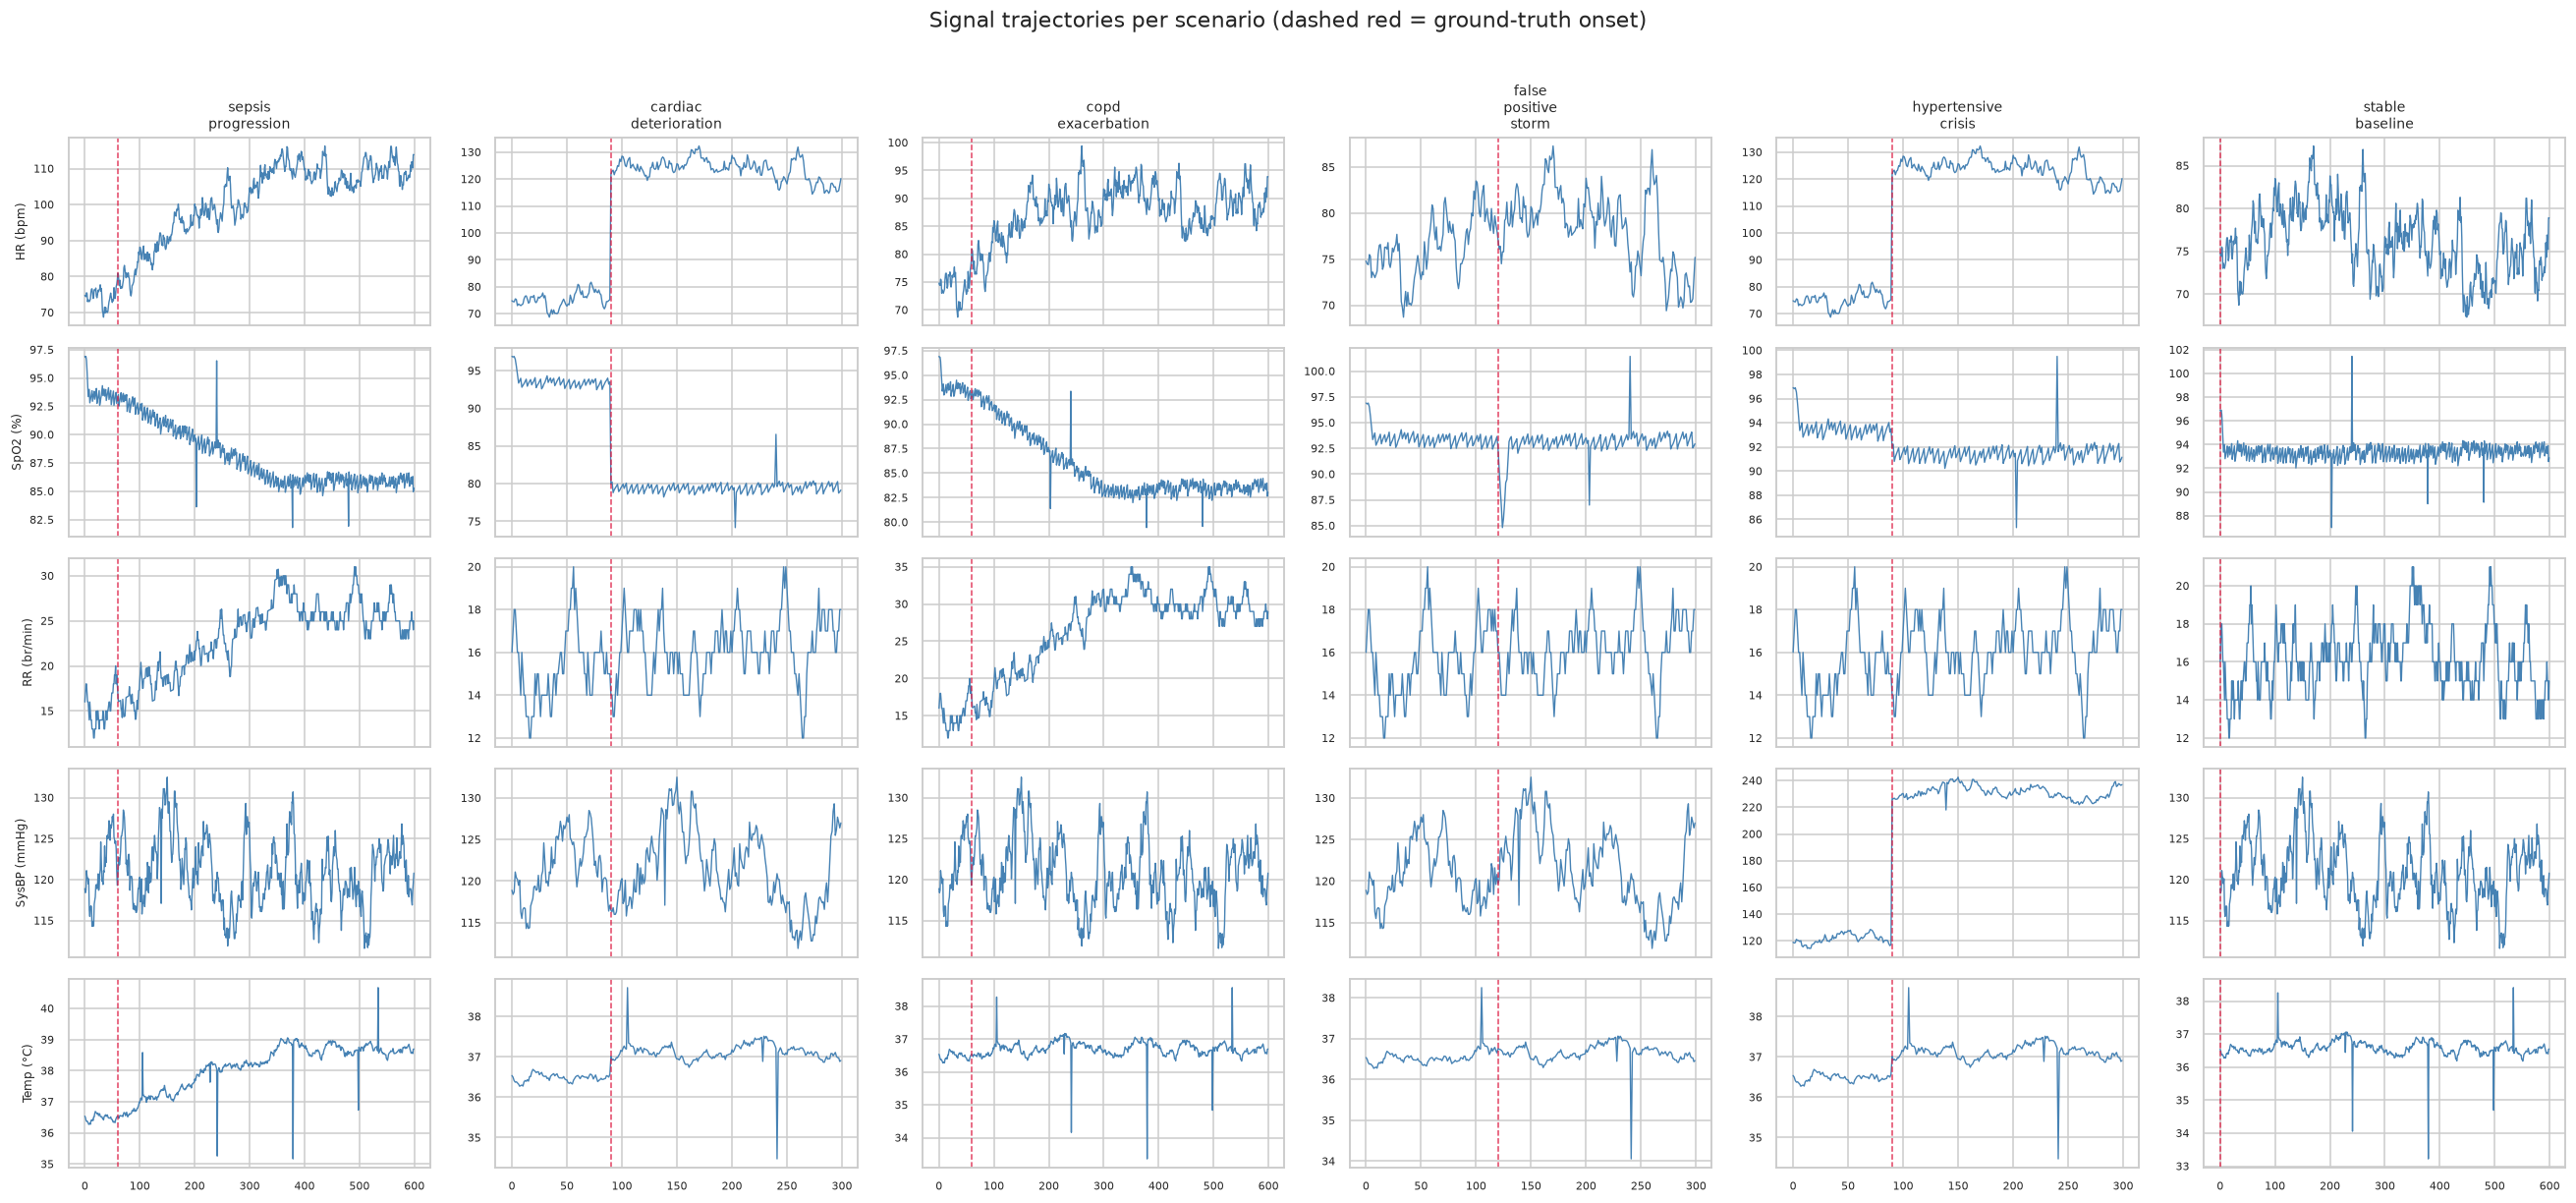

In [23]:
SIGNAL_PANELS = ["heart_rate", "spo2", "respiratory_rate", "systolic_bp", "temperature"]
SIGNAL_LABELS = {
    "heart_rate": "HR (bpm)", "spo2": "SpO2 (%)", "respiratory_rate": "RR (br/min)",
    "systolic_bp": "SysBP (mmHg)", "temperature": "Temp (°C)",
}

fig, axes = plt.subplots(len(SIGNAL_PANELS), len(SCENARIO_ORDER),
                          figsize=(4 * len(SCENARIO_ORDER), 2.2 * len(SIGNAL_PANELS)),
                          sharex="col")

for col, scenario_id in enumerate(SCENARIO_ORDER):
    onset_s = SCENARIOS[scenario_id].onset_offset_ms / 1000
    for row, sig in enumerate(SIGNAL_PANELS):
        ax = axes[row, col]
        d = signals_df[(signals_df.scenario == scenario_id) & (signals_df.signal_type == sig)]
        ax.plot(d.elapsed_s, d.value, lw=0.9, color="steelblue")
        ax.axvline(onset_s, color="crimson", ls="--", lw=1, alpha=0.8)
        if row == 0:
            ax.set_title(scenario_id.replace("_", "\n"), fontsize=9)
        if col == 0:
            ax.set_ylabel(SIGNAL_LABELS[sig], fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle("Signal trajectories per scenario (dashed red = ground-truth onset)", y=1.01)
fig.tight_layout()
plt.show()

## 2. Inter-Signal Correlation

`data/generators/correlation.py` nudges SpO2/Temp/SysBP based on each patient's *own* latest HR/RR deviation from baseline — this is what makes composite EWS scoring meaningful (independent per-signal noise would let a NEWS2 score fire on unrealistic combinations). Below: z-scored overlay of the sepsis run (HR up, Temp up, SpO2 down should move together after onset) and the actual pre/post-onset Pearson correlation between HR deviation and SpO2 deviation.

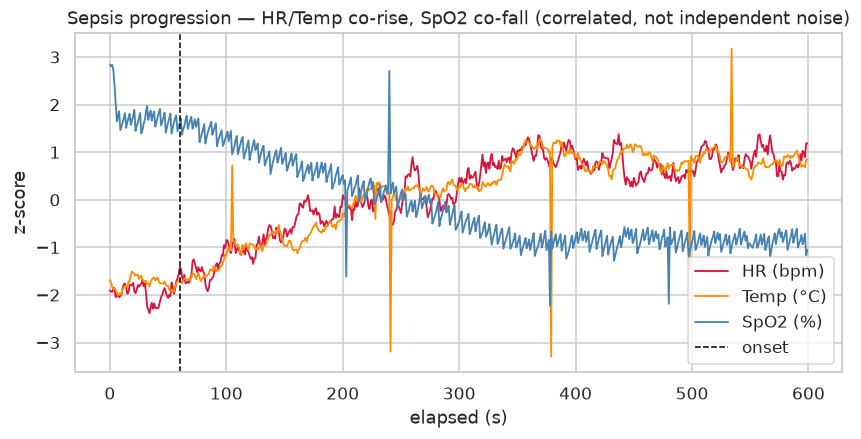

HR vs SpO2 Pearson r — pre-onset: -0.094   post-onset: -0.928  (expected: more negative post-onset)


In [24]:
sepsis = signals_df[signals_df.scenario == "sepsis_progression"]
onset_ms = SCENARIOS["sepsis_progression"].onset_offset_ms

fig, ax = plt.subplots(figsize=(9, 4))
for sig, color in [("heart_rate", "crimson"), ("temperature", "darkorange"), ("spo2", "steelblue")]:
    d = sepsis[sepsis.signal_type == sig].sort_values("elapsed_ms")
    z = (d.value - d.value.mean()) / d.value.std()
    ax.plot(d.elapsed_s, z, label=SIGNAL_LABELS.get(sig, sig), color=color, lw=1.2)
ax.axvline(onset_ms / 1000, color="black", ls="--", lw=1, label="onset")
ax.set_xlabel("elapsed (s)"); ax.set_ylabel("z-score")
ax.set_title("Sepsis progression — HR/Temp co-rise, SpO2 co-fall (correlated, not independent noise)")
ax.legend()
plt.show()

# Quantify: HR deviation vs SpO2 deviation correlation, before vs after onset
hr = sepsis[sepsis.signal_type == "heart_rate"].set_index("elapsed_ms").value
spo2 = sepsis[sepsis.signal_type == "spo2"].set_index("elapsed_ms").value
joined = pd.merge_asof(hr.reset_index().sort_values("elapsed_ms"),
                        spo2.reset_index().sort_values("elapsed_ms"),
                        on="elapsed_ms", suffixes=("_hr", "_spo2"), direction="nearest")
pre = joined[joined.elapsed_ms < onset_ms]
post = joined[joined.elapsed_ms >= onset_ms]
print(f"HR vs SpO2 Pearson r — pre-onset: {pre.value_hr.corr(pre.value_spo2):+.3f}   "
      f"post-onset: {post.value_hr.corr(post.value_spo2):+.3f}  (expected: more negative post-onset)")

## 3. Transport Noise & Dropout Injection

`data/generators/noise.py` (`NoiseInjector`) — packet loss, outlier spikes, and dropout windows, seeded independently (`noise_seed`) from the physiological signal (`signal_seed`). Below: heart-rate on `stable_baseline` under an exaggerated noise config so the effect is visible — dropped readings (red) and spikes (orange) marked on top of the clean signal.

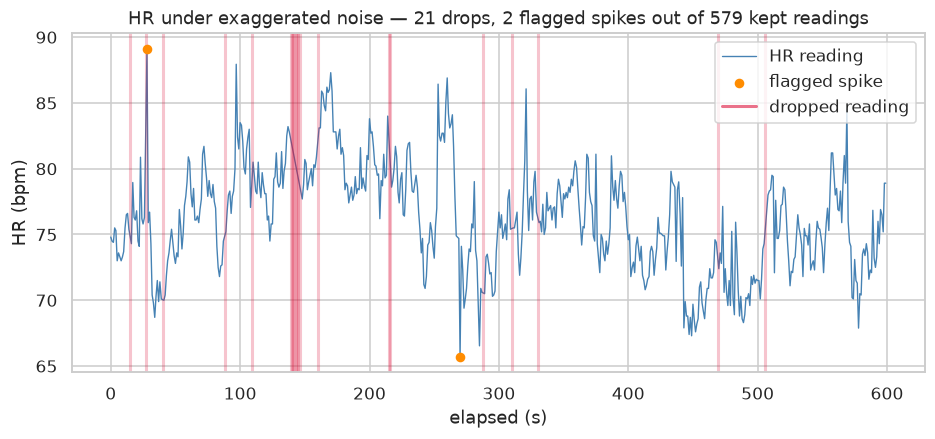

In [25]:
LOUD_NOISE = NoiseConfig(
    packet_loss_rate=0.03, spike_probability=0.04, spike_magnitude_pct=0.15,
    dropout_probability=0.01, dropout_duration_s=8, clock_drift_ms=50,
)

noisy_rec = []
_simulate_run(SCENARIOS["stable_baseline"], DEMO_SEED, DEMO_SEED + 1, LOUD_NOISE, record=noisy_rec)
noisy_df = pd.DataFrame(noisy_rec)

hr_noisy = noisy_df[(noisy_df.kind == "signal") & (noisy_df.signal_type == "heart_rate")].sort_values("elapsed_ms").copy()
hr_dropped = noisy_df[(noisy_df.kind == "dropped") & (noisy_df.signal_type == "heart_rate")]

rolling_med = hr_noisy.value.rolling(7, center=True, min_periods=1).median()
is_spike = (hr_noisy.value - rolling_med).abs() > 8  # simple outlier flag for the chart

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hr_noisy.elapsed_ms / 1000, hr_noisy.value, lw=0.9, color="steelblue", label="HR reading")
ax.scatter(hr_noisy.elapsed_ms[is_spike] / 1000, hr_noisy.value[is_spike],
           color="darkorange", s=28, zorder=5, label="flagged spike")
for t in hr_dropped.elapsed_ms / 1000:
    ax.axvline(t, color="crimson", alpha=0.25, lw=2)
ax.plot([], [], color="crimson", alpha=0.6, lw=2, label="dropped reading")  # legend proxy
ax.set_xlabel("elapsed (s)"); ax.set_ylabel("HR (bpm)")
ax.set_title(f"HR under exaggerated noise — {len(hr_dropped)} drops, {is_spike.sum()} flagged spikes out of {len(hr_noisy)} kept readings")
ax.legend()
plt.show()

## 4. NEWS2 Composite Scoring — Approaches A / B / C on One Run

`cardiac_deterioration` (sudden step) run: Approach C (continuous, every message) vs Approach B (fixed ~60s tick) NEWS2 score over time, plus every Approach A per-signal alarm as a tick mark. This is the core thesis comparison figure — detection-latency difference is directly visible as the horizontal gap between the onset line and each approach's first alarm marker.

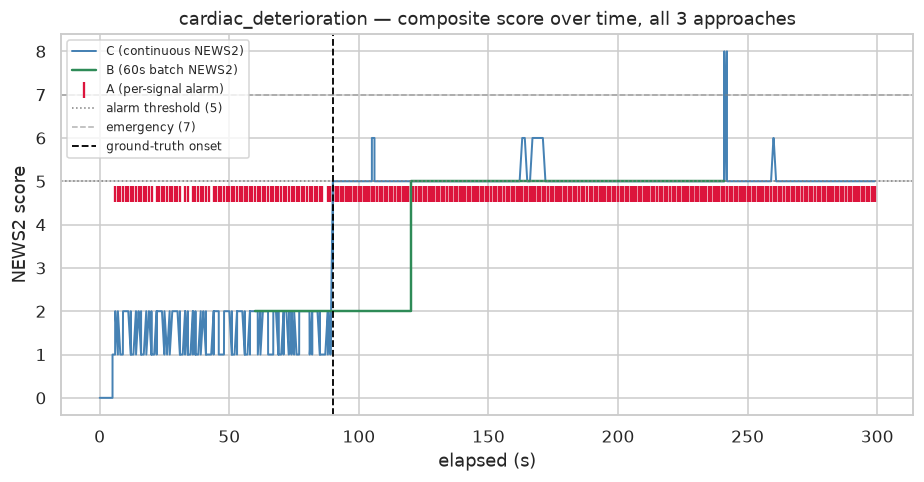

First alarm after onset (elapsed ms, lower = faster detection):
  A: -83952
  B: 29994
  C: -18


In [26]:
from brain.ews_scorer import ALARM_THRESHOLD, EMERGENCY_THRESHOLD

cardiac_rec = []
_simulate_run(SCENARIOS["cardiac_deterioration"], DEMO_SEED, DEMO_SEED + 1, DEFAULT_NOISE, record=cardiac_rec)
cardiac_df = pd.DataFrame(cardiac_rec)
onset_ms = SCENARIOS["cardiac_deterioration"].onset_offset_ms

comp_c = cardiac_df[cardiac_df.kind == "composite_c"].sort_values("elapsed_ms")
comp_b = cardiac_df[cardiac_df.kind == "composite_b"].sort_values("elapsed_ms")
alarm_a = cardiac_df[cardiac_df.kind == "alarm_a"]

first_a = alarm_a.elapsed_ms.min() if len(alarm_a) else None
first_c = comp_c[comp_c.news2_score >= ALARM_THRESHOLD].elapsed_ms.min() if (comp_c.news2_score >= ALARM_THRESHOLD).any() else None
first_b = comp_b[comp_b.news2_score >= ALARM_THRESHOLD].elapsed_ms.min() if (comp_b.news2_score >= ALARM_THRESHOLD).any() else None

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(comp_c.elapsed_ms / 1000, comp_c.news2_score, color="steelblue", lw=1.3, label="C (continuous NEWS2)")
ax.step(comp_b.elapsed_ms / 1000, comp_b.news2_score, color="seagreen", lw=1.6, where="post", label="B (60s batch NEWS2)")
ax.scatter(alarm_a.elapsed_ms / 1000, [ALARM_THRESHOLD - 0.3] * len(alarm_a),
           marker="|", color="crimson", s=120, label="A (per-signal alarm)")

ax.axhline(ALARM_THRESHOLD, color="gray", ls=":", lw=1, label=f"alarm threshold ({ALARM_THRESHOLD})")
ax.axhline(EMERGENCY_THRESHOLD, color="gray", ls="--", lw=1, alpha=0.6, label=f"emergency ({EMERGENCY_THRESHOLD})")
ax.axvline(onset_ms / 1000, color="black", ls="--", lw=1.2, label="ground-truth onset")

ax.set_xlabel("elapsed (s)"); ax.set_ylabel("NEWS2 score")
ax.set_title("cardiac_deterioration — composite score over time, all 3 approaches")
ax.legend(loc="upper left", fontsize=8)
plt.show()

print("First alarm after onset (elapsed ms, lower = faster detection):")
print(f"  A: {first_a - onset_ms if first_a else 'never'}")
print(f"  B: {first_b - onset_ms if first_b else 'never'}")
print(f"  C: {first_c - onset_ms if first_c else 'never'}")

## 5. Benchmark Results — Full Sweep (10 seed pairs × 6 scenarios × 3 approaches)

Loaded from `benchmark_results.csv` (produced by `scripts/run_benchmark.py --runs 10`). TPR/FPR are only defined per scenario's ground truth (`expect_alarm`) — deterioration scenarios (`sepsis_progression`, `cardiac_deterioration`, `copd_exacerbation`, `hypertensive_crisis`) report TPR only; no-event scenarios (`false_positive_storm`, `stable_baseline`) report FPR only. That's why the TPR and FPR panels below each only show 4 and 2 scenarios respectively — the other scenarios have no ground-truth label for that metric, not missing data.

**Why Approach A's FPR is higher than B/C (not a bug — this is the core hypothesis):** Approach A alarms whenever *any single signal* crosses its own warning/critical threshold. Both no-event scenarios are specifically designed to trip a single signal transiently (`false_positive_storm`) or just via ordinary physiological noise (`stable_baseline`) without a real composite deterioration. B/C require the *aggregate* NEWS2 score (across all 5 signals) to reach the alarm threshold, which a single transient signal usually can't do alone — so they fire far less often on these scenarios. A having FPR ≈ 1.0 while B/C stay near 0 is the expected result being measured, not noise in the chart.

In [27]:
bench = pd.read_csv(BENCHMARK_CSV)
bench["scenario"] = pd.Categorical(bench["scenario"], categories=SCENARIO_ORDER, ordered=True)
print(f"{len(bench)} rows, {bench.signal_seed.nunique()} seed pairs per (scenario, approach)")
bench.head()

180 rows, 10 seed pairs per (scenario, approach)


,scenario,signal_seed,noise_seed,approach,TPR,FPR,detection_latency_ms,alarm_rate_per_day,p99_pipeline_latency_ms
0,sepsis_progression,1000,2000,A,1.0,NaN,44.0,235296.0,NaN
1,sepsis_progression,1000,2000,B,1.0,NaN,180994.0,864.0,NaN
2,sepsis_progression,1000,2000,C,1.0,NaN,22998.0,304128.0,NaN
3,sepsis_progression,2000,4000,A,1.0,NaN,47.0,235584.0,NaN
4,sepsis_progression,2000,4000,B,1.0,NaN,181050.0,864.0,NaN


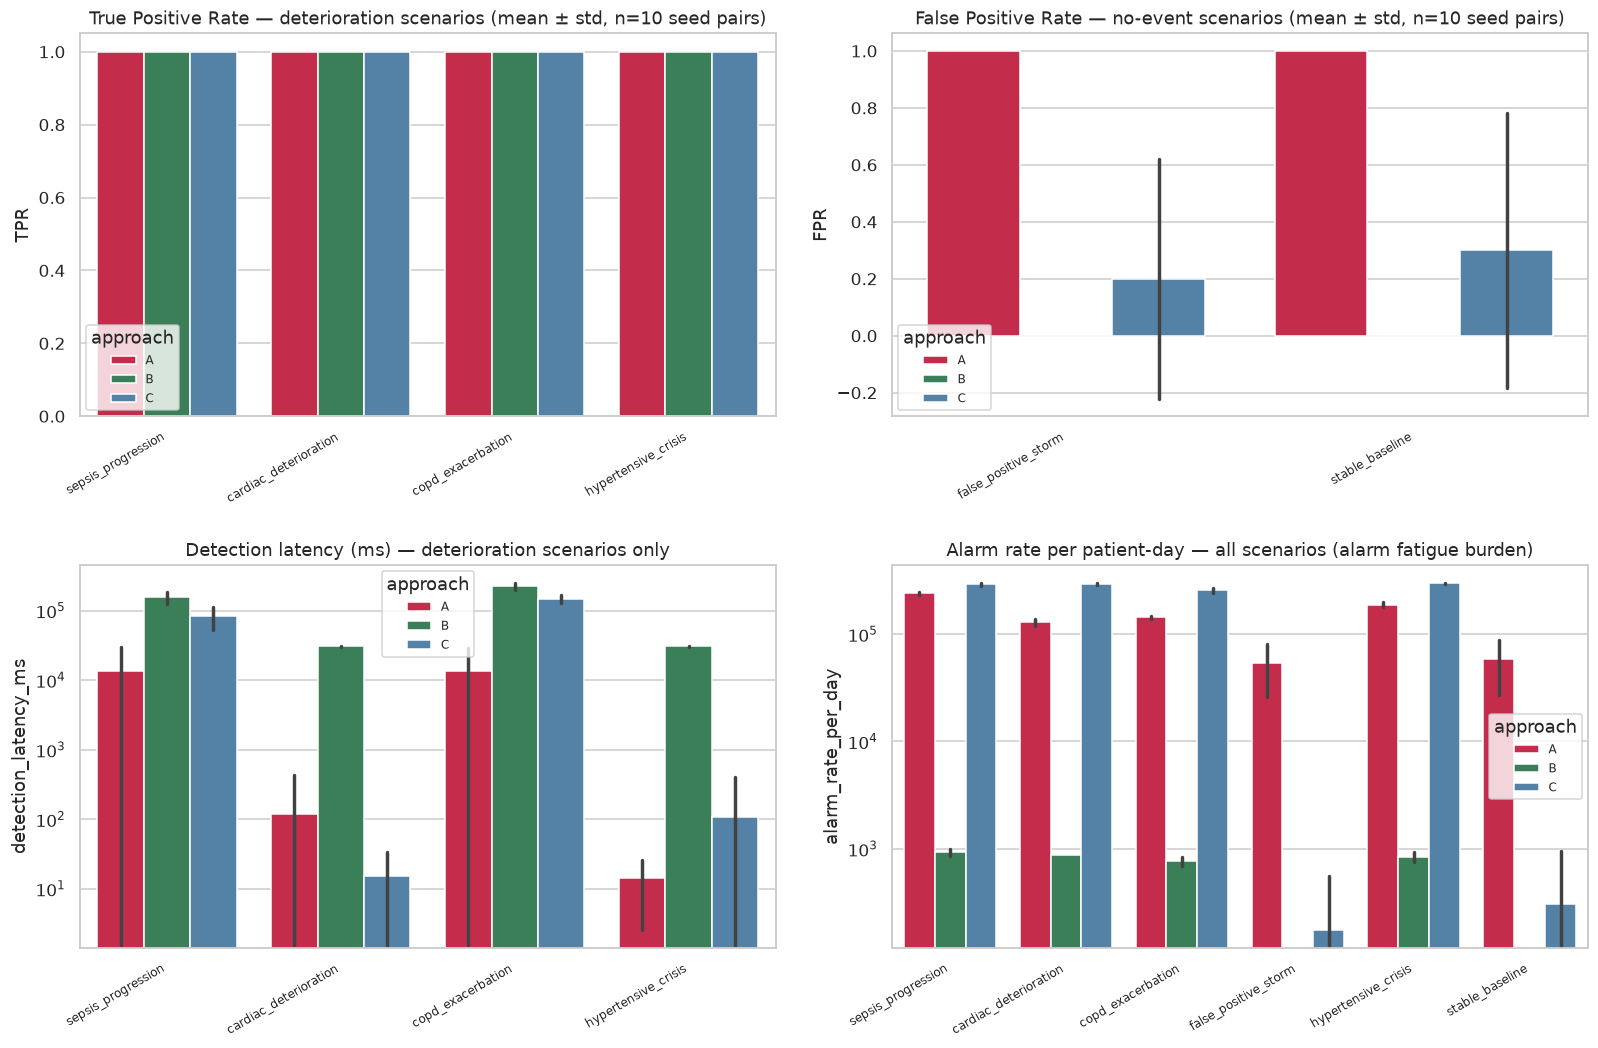

In [28]:
APPROACH_COLORS = {"A": "crimson", "B": "seagreen", "C": "steelblue"}
tpr_df = bench.dropna(subset=["TPR"])
fpr_df = bench.dropna(subset=["FPR"])

# Restrict each panel's x-order to scenarios that actually have that metric —
# otherwise the shared Categorical dtype reserves an empty slot for every
# scenario, leaving blank gaps where TPR/FPR is undefined by ground truth.
tpr_order = [s for s in SCENARIO_ORDER if s in tpr_df.scenario.unique()]
fpr_order = [s for s in SCENARIO_ORDER if s in fpr_df.scenario.unique()]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=tpr_df, x="scenario", y="TPR", hue="approach", order=tpr_order,
            palette=APPROACH_COLORS, errorbar="sd", ax=axes[0, 0])
axes[0, 0].set_title("True Positive Rate — deterioration scenarios (mean ± std, n=10 seed pairs)")

sns.barplot(data=fpr_df, x="scenario", y="FPR", hue="approach", order=fpr_order,
            palette=APPROACH_COLORS, errorbar="sd", ax=axes[0, 1])
axes[0, 1].set_title("False Positive Rate — no-event scenarios (mean ± std, n=10 seed pairs)")

sns.barplot(data=tpr_df, x="scenario", y="detection_latency_ms", hue="approach", order=tpr_order,
            palette=APPROACH_COLORS, errorbar="sd", ax=axes[1, 0])
axes[1, 0].set_title("Detection latency (ms) — deterioration scenarios only")
axes[1, 0].set_yscale("log")

sns.barplot(data=bench, x="scenario", y="alarm_rate_per_day", hue="approach", order=SCENARIO_ORDER,
            palette=APPROACH_COLORS, errorbar="sd", ax=axes[1, 1])
axes[1, 1].set_title("Alarm rate per patient-day — all scenarios (alarm fatigue burden)")
axes[1, 1].set_yscale("log")

for ax in axes.flat:
    ax.legend(title="approach", fontsize=8)
    ax.set_xlabel("")
    for label in ax.get_xticklabels():
        label.set_rotation(30)
        label.set_ha("right")
        label.set_fontsize(8)

fig.tight_layout(pad=2.0)
plt.show()

## 6. Summary Table (paper-ready)

Mean ± std per (scenario, approach) — this is the table to drop into the thesis results section.

In [29]:
def mean_std(s):
    return f"{s.mean():.3g} ± {s.std():.3g}" if s.notna().any() else "—"

summary = (
    bench.groupby(["scenario", "approach"], observed=True)
    .agg(TPR=("TPR", mean_std), FPR=("FPR", mean_std),
         detection_latency_ms=("detection_latency_ms", mean_std),
         alarm_rate_per_day=("alarm_rate_per_day", mean_std))
    .reset_index()
)
summary

,scenario,approach,TPR,FPR,detection_latency_ms,alarm_rate_per_day
0,sepsis_progression,A,1 ± 0,—,1.37e+04 ± 1.6e+04,2.4e+05 ± 7.76e+03
1,sepsis_progression,B,1 ± 0,—,1.57e+05 ± 3.1e+04,922 ± 74.4
2,sepsis_progression,C,1 ± 0,—,8.27e+04 ± 2.96e+04,2.91e+05 ± 1.14e+04
3,cardiac_deterioration,A,1 ± 0,—,120 ± 313,1.29e+05 ± 8.83e+03
4,cardiac_deterioration,B,1 ± 0,—,3.04e+04 ± 502,864 ± 0
5,cardiac_deterioration,C,1 ± 0,—,15.2 ± 18.1,2.95e+05 ± 5.16e+03
6,copd_exacerbation,A,1 ± 0,—,1.36e+04 ± 1.57e+04,1.44e+05 ± 4.77e+03
7,copd_exacerbation,B,1 ± 0,—,2.24e+05 ± 2.91e+04,763 ± 69.6
8,copd_exacerbation,C,1 ± 0,—,1.47e+05 ± 2.02e+04,2.56e+05 ± 1.47e+04
9,false_positive_storm,A,—,1 ± 0,—,5.34e+04 ± 2.75e+04


### 6b. Spread Between Approaches (detection latency, alarm rate)

Per scenario: each approach's mean, plus a `spread (max-min)` column quantifying how much the approaches disagree — the number that actually matters for "does the scoring approach change the outcome."

In [30]:
numeric_means = bench.groupby(["scenario", "approach"], observed=True).agg(
    detection_latency_ms=("detection_latency_ms", "mean"),
    alarm_rate_per_day=("alarm_rate_per_day", "mean"),
).reset_index()

def pivot_with_spread(metric):
    p = numeric_means.pivot(index="scenario", columns="approach", values=metric)
    p = p.reindex(SCENARIO_ORDER)
    p["spread (max-min)"] = p.max(axis=1) - p.min(axis=1)
    return p.round(1)

print("Detection latency (ms) — lower is faster; blank rows have no ground-truth onset (no-event scenarios)")
display(pivot_with_spread("detection_latency_ms"))

print("\nAlarm rate per patient-day — lower is less alarm fatigue")
display(pivot_with_spread("alarm_rate_per_day"))

Detection latency (ms) — lower is faster; blank rows have no ground-truth onset (no-event scenarios)


approach,A,B,C,spread (max-min)
scenario,,,,
sepsis_progression,13718.4,156831.7,82692.2,143113.3
cardiac_deterioration,120.1,30429.4,15.2,30414.2
copd_exacerbation,13616.4,223515.2,146669.6,209898.8
false_positive_storm,NaN,NaN,NaN,NaN
hypertensive_crisis,14.1,30429.4,106.8,30415.3
stable_baseline,NaN,NaN,NaN,NaN



Alarm rate per patient-day — lower is less alarm fatigue


approach,A,B,C,spread (max-min)
scenario,,,,
sepsis_progression,240480.0,921.6,291412.8,290491.2
cardiac_deterioration,129052.8,864.0,295142.4,294278.4
copd_exacerbation,144403.2,763.2,256190.4,255427.2
false_positive_storm,53366.4,0.0,172.8,53366.4
hypertensive_crisis,187632.0,835.2,297590.4,296755.2
stable_baseline,58132.8,0.0,302.4,58132.8
